# Endline Survey EDA (Existing Businesses 2022-2025)

Detailed endline exploratory analysis focusing on:

- Endline business and demographic profile
- Data quality and missingness diagnostics
- Performance outcomes (revenue, expenses, jobs)
- NPS and satisfaction decomposition
- Segment-level insights by location and sector

In [6]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 160)
np.random.seed(42)

In [7]:
def find_ml_root() -> Path:
    cwd = Path.cwd().resolve()
    for p in [cwd, *cwd.parents]:
        if (p / 'Anomynized data').exists() and (p / 'notebooks').exists():
            return p
        if (p / 'ml' / 'Anomynized data').exists():
            return p / 'ml'
    raise FileNotFoundError('Could not locate ml root containing Anomynized data directory.')

def load_csv_with_fallback(csv_path: Path) -> pd.DataFrame:
    for enc in ['utf-8', 'latin-1', 'cp1252']:
        try:
            return pd.read_csv(csv_path, encoding=enc)
        except UnicodeDecodeError:
            continue
    # Last resort: replace undecodable bytes to avoid hard failure in EDA.
    return pd.read_csv(csv_path, encoding='utf-8', encoding_errors='replace')

ml_root = find_ml_root()
data_dir = ml_root / 'Anomynized data' / 'Anomynized data' / 'Anomynized data'
csv_path = data_dir / 'endline_RW-ET-SS_existing businesses 2022-2025_Inkomoko.csv'

df = load_csv_with_fallback(csv_path)
print(f'Shape: {df.shape}')
display(df.head())

Shape: (8976, 26)


,client_id,country,survey_date,age,gender,strata,client_location,nationality,education_level,business_sector,only_income_earner,number_of_people_reponsible,business_location,is_business_registered,has_access_to_finance_in_past6months,have_bank_account,monthly_customer,kept_sales_record,job_created,revenue,hh_expense,nps_detractor,nps_passive,nps_promoter,satisfied_yes,satisfied_no
0,EB2E2F413E84742BFAA4,Rwanda,16/12/2022,34,Female,Refugee,Gatsibo,Congolese,Attended Primary,NaN,Yes,0.0,Gatsibo,No,No,No,50.0,Yes,1.0,4.686036,NaN,0.0,1.0,0.0,1.0,0.0
1,3AFDDC837F7708726702,Rwanda,18/12/2022,34,Male,Refugee,Gatsibo,Congolese,Finished High School Graduate,NaN,Yes,3.0,Gatsibo,No,No,Yes,55.0,Yes,2.0,56.232427,NaN,0.0,1.0,0.0,1.0,0.0
2,88293FF22ABB9BB12782,Rwanda,15/12/2022,32,Male,Refugee,Gatsibo,Congolese,Finished High School Graduate,NaN,Yes,4.0,Gatsibo,No,No,Yes,200.0,Yes,1.0,93.720712,NaN,0.0,1.0,0.0,1.0,0.0
3,831D6EC548106E45FC8B,Rwanda,12/07/2022,32,Male,Refugee,Nyabiheke Camp,Congolese,Attended High School,NaN,Yes,3.0,Nyabiheke Camp,No,No,Yes,900.0,Yes,4.0,2061.855670,NaN,0.0,1.0,0.0,1.0,0.0
4,3E9937B916EB192B1A0D,Rwanda,16/12/2022,30,Female,Refugee,Gatsibo,Congolese,Finished High School Graduate,NaN,Yes,3.0,Gatsibo,No,No,Yes,180.0,Yes,2.0,243.673852,NaN,0.0,1.0,0.0,1.0,0.0


In [8]:
if 'survey_date' in df.columns:
    df['survey_date'] = pd.to_datetime(df['survey_date'], errors='coerce', dayfirst=True)

for c in ['age', 'number_of_people_reponsible', 'monthly_customer', 'job_created', 'revenue', 'hh_expense', 'nps_detractor', 'nps_passive', 'nps_promoter', 'satisfied_yes', 'satisfied_no']:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors='coerce')

schema = pd.DataFrame({
    'column': df.columns,
    'dtype': [str(df[c].dtype) for c in df.columns],
    'null_count': [int(df[c].isna().sum()) for c in df.columns],
    'null_pct': [round(df[c].isna().mean() * 100, 2) for c in df.columns],
    'n_unique': [int(df[c].nunique(dropna=True)) for c in df.columns]
}).sort_values('null_pct', ascending=False)
display(schema)

,column,dtype,null_count,null_pct,n_unique
13,is_business_registered,object,5976,66.58,2
20,hh_expense,float64,5843,65.10,1648
14,has_access_to_finance_in_past6months,object,5710,63.61,4
24,satisfied_yes,float64,5438,60.58,2
25,satisfied_no,float64,5438,60.58,2
10,only_income_earner,object,5413,60.31,2
15,have_bank_account,object,5410,60.27,2
11,number_of_people_reponsible,float64,2298,25.60,25
9,business_sector,object,858,9.56,63
16,monthly_customer,float64,807,8.99,577


,missing_pct
is_business_registered,66.58
hh_expense,65.10
has_access_to_finance_in_past6months,63.61
satisfied_yes,60.58
satisfied_no,60.58
only_income_earner,60.31
have_bank_account,60.27
number_of_people_reponsible,25.60
business_sector,9.56
monthly_customer,8.99


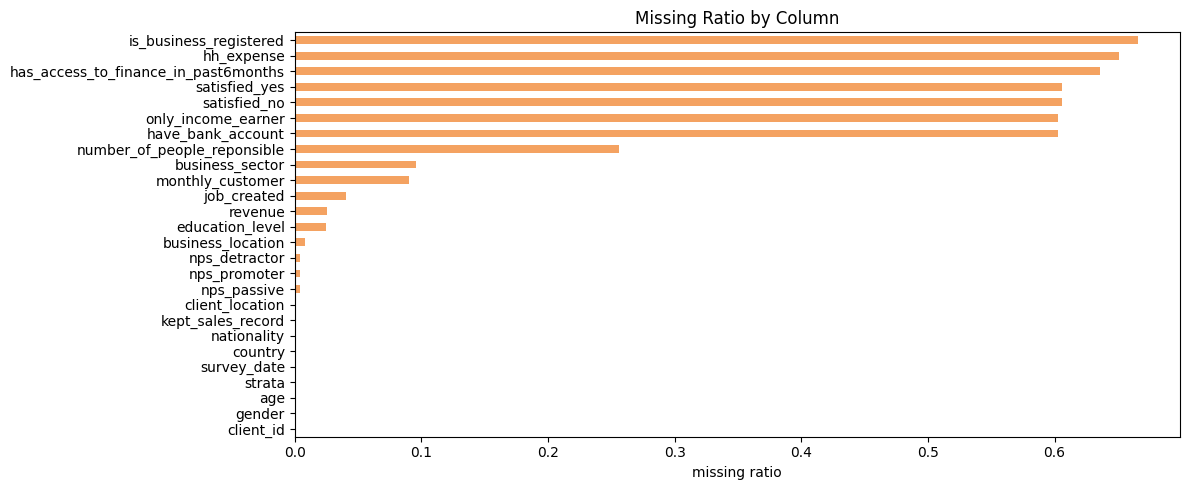

,count
gender,
Female,5516
Male,3460


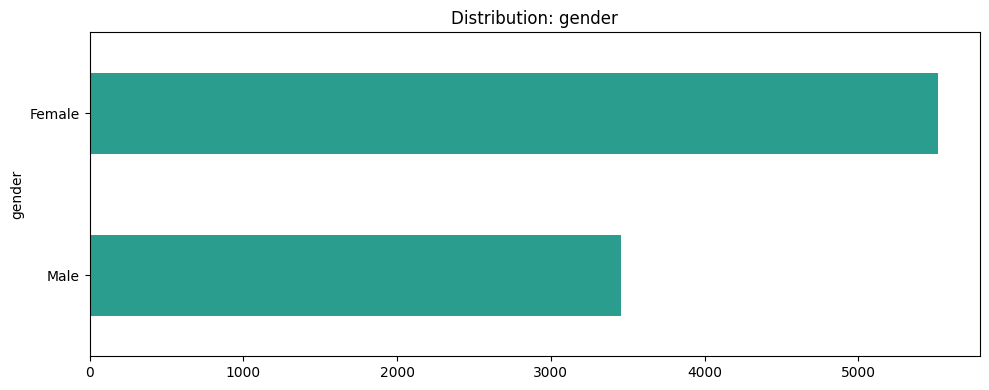

,count
nationality,
Rwandan,4990
Ethiopian,1016
Congolese,962
Sudanese,664
Somali,447
Burundian,370
South Sudanese,268
Eritrean,247
Yemeni,7


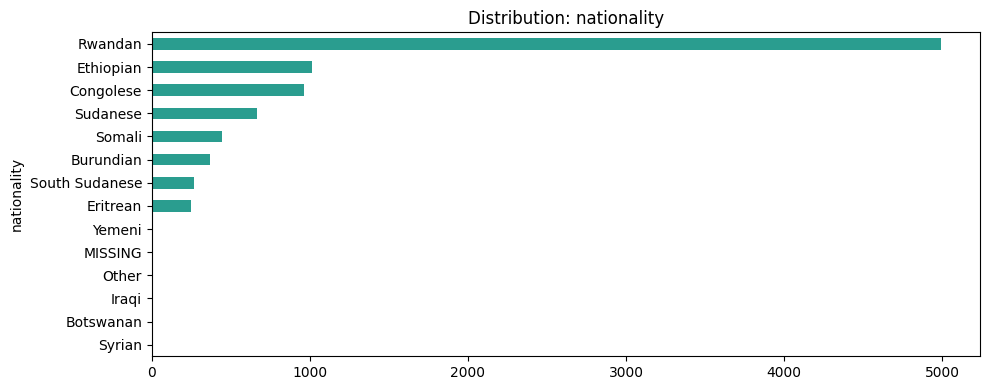

,count
education_level,
Attended High School,2043
Finished High School/Graduate,1210
Finished Primary School,1124
Attended Primary School,924
No Formal Education,664
Attended Primary,429
Finished Primary,306
Diploma,274
Finished High School Graduate,231


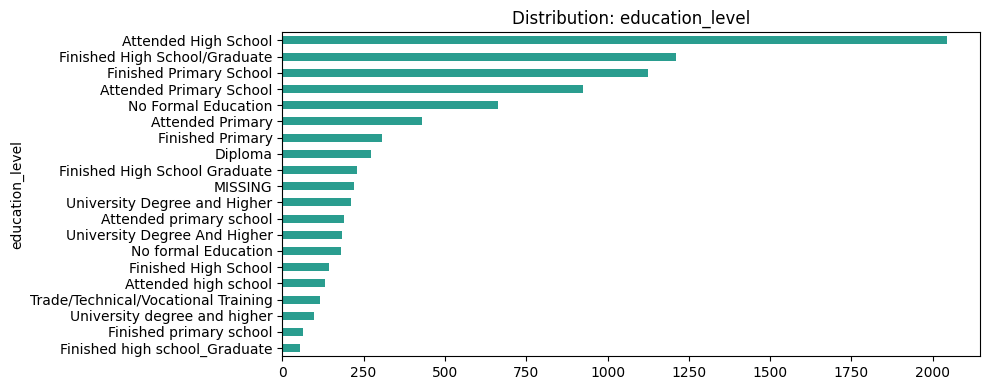

,count
business_sector,
Retail Sales and Grocery,2309
Fashion and Apparel,1201
MISSING,858
Food and Beverage Retail,809
"Agribusiness,Processing,and Farming",782
"Tech,Digital Services,Ecommerce",540
Fashion And Apparel,268
Retail Shop,238
Retail Sales And Grocery,192


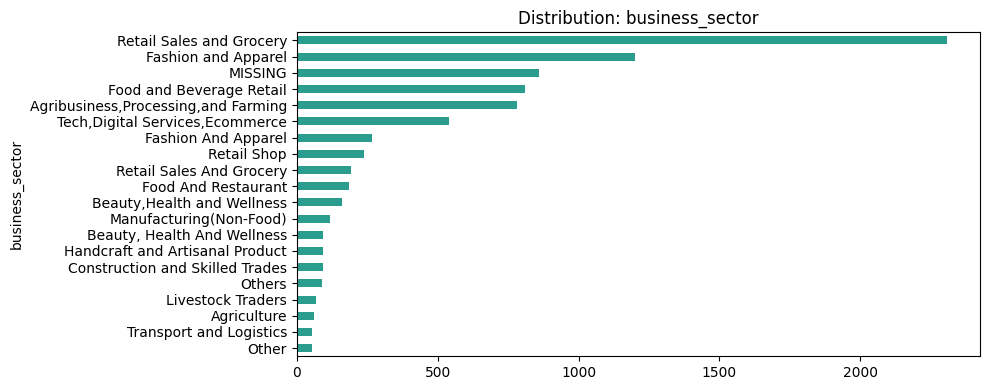

,count
business_location,
Musanze,673
Rusizi,644
Huye,618
Kayonza,475
Gatsibo,387
Karongi,344
Kirehe,335
Nyamagabe,330
Kebribeyah Town,311


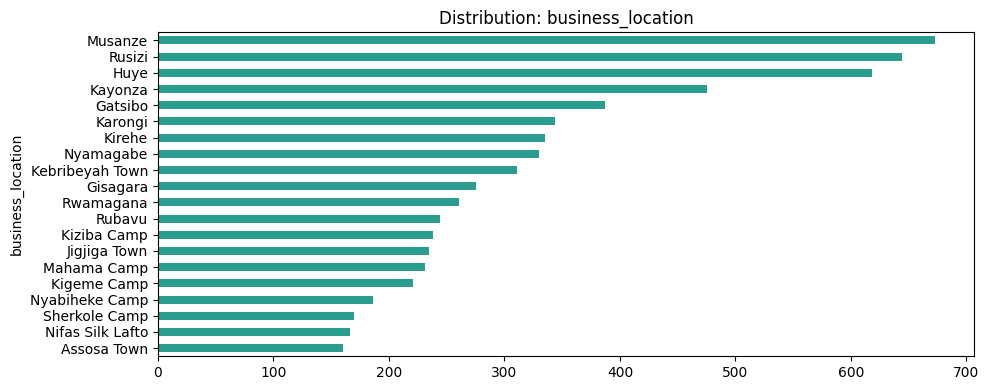

,count
strata,
Host,6008
Refugee,2968


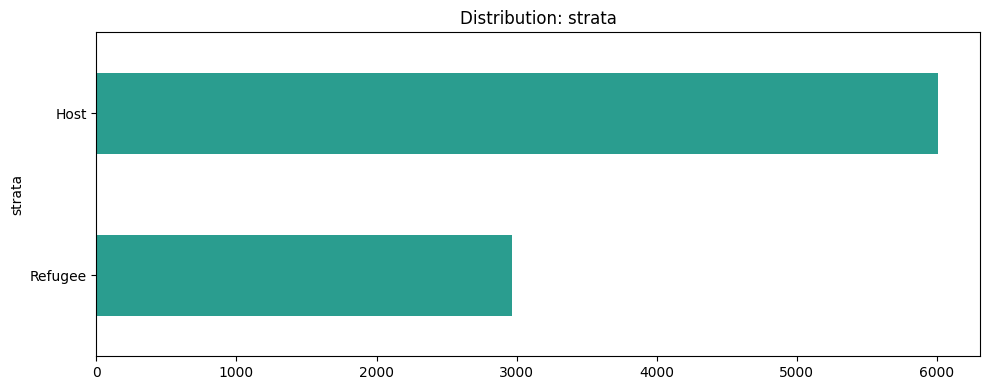

In [9]:
missing = df.isna().mean().sort_values(ascending=False)
display((missing * 100).round(2).rename('missing_pct').to_frame())

fig, ax = plt.subplots(figsize=(12, 5))
missing.sort_values(ascending=True).plot(kind='barh', ax=ax, color='#f4a261')
ax.set_title('Missing Ratio by Column')
ax.set_xlabel('missing ratio')
plt.tight_layout()
plt.show()

cat_cols = ['gender', 'nationality', 'education_level', 'business_sector', 'business_location', 'strata']
for c in cat_cols:
    if c in df.columns:
        vc = df[c].fillna('MISSING').value_counts().head(20)
        display(vc.rename('count').to_frame())
        fig, ax = plt.subplots(figsize=(10, 4))
        vc.sort_values().plot(kind='barh', ax=ax, color='#2a9d8f')
        ax.set_title(f'Distribution: {c}')
        plt.tight_layout()
        plt.show()

,count,mean,std,min,1%,5%,50%,95%,99%,max
age,8976.0,34.508244,9.589975,18.0,19.000000,22.0000,33.000000,52.000000,61.000000,8.100000e+01
number_of_people_reponsible,6678.0,4.546271,3.140445,0.0,1.000000,1.0000,4.000000,11.000000,14.000000,2.500000e+01
monthly_customer,8169.0,2032.699718,67123.514012,0.0,2.000000,3.0000,312.000000,1532.400000,2816.000000,5.170000e+06
job_created,8615.0,2.006268,4.231485,0.0,0.000000,0.0000,1.000000,7.000000,16.000000,1.590000e+02
revenue,8745.0,1491.962490,3488.033380,0.0,13.838527,52.0610,578.461000,5672.040086,13367.341768,1.090909e+05
hh_expense,3133.0,197.260787,229.601700,0.0,2.301825,20.3125,156.131507,501.929229,809.557384,6.486364e+03


,revenue_expense_ratio
count,3118.000000
mean,293.304385
std,8887.829820
min,0.000000
25%,3.076923
50%,6.454973
75%,14.541378
max,337499.996946


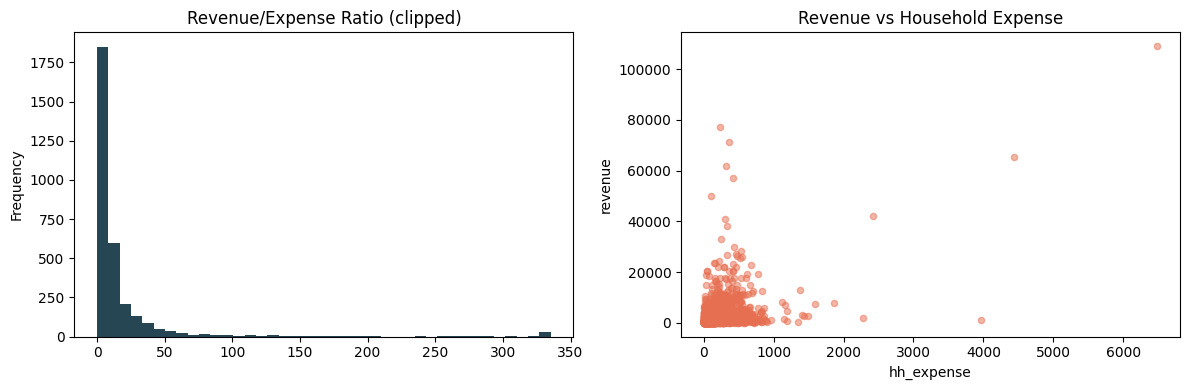

,count,mean,sum
business_sector,,,
Manufacturing _non-food_,1,12.000000,12.0
Fashion - Tailoring,34,10.117647,344.0
Energy,3,9.000000,27.0
Hospitality And Tourism Ð Restaurant/Bar,1,7.000000,7.0
Tourism And Hospitality,15,6.933333,104.0
...,...,...,...
"Tech, Digital Services, eCommerce",8,0.875000,7.0
Retail Sales and Grocery,2173,0.854119,1856.0
Fashion and Apparel,1152,0.709201,817.0


In [10]:
num_cols = [c for c in ['age', 'number_of_people_reponsible', 'monthly_customer', 'job_created', 'revenue', 'hh_expense'] if c in df.columns]
display(df[num_cols].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]).T)

if {'revenue', 'hh_expense'}.issubset(df.columns):
    ratio = df['revenue'] / df['hh_expense'].replace(0, np.nan)
    display(ratio.describe().rename('revenue_expense_ratio').to_frame())

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    ratio.dropna().clip(upper=ratio.quantile(0.99)).plot(kind='hist', bins=40, ax=axes[0], color='#264653')
    axes[0].set_title('Revenue/Expense Ratio (clipped)')
    df.plot(kind='scatter', x='hh_expense', y='revenue', alpha=0.5, ax=axes[1], color='#e76f51')
    axes[1].set_title('Revenue vs Household Expense')
    plt.tight_layout()
    plt.show()

if {'business_sector', 'job_created'}.issubset(df.columns):
    sec_jobs = df.groupby('business_sector')['job_created'].agg(['count', 'mean', 'sum']).sort_values('mean', ascending=False)
    display(sec_jobs)

,count,pct
nps_detractor,578.0,6.47
nps_passive,2776.0,31.06
nps_promoter,5584.0,62.47


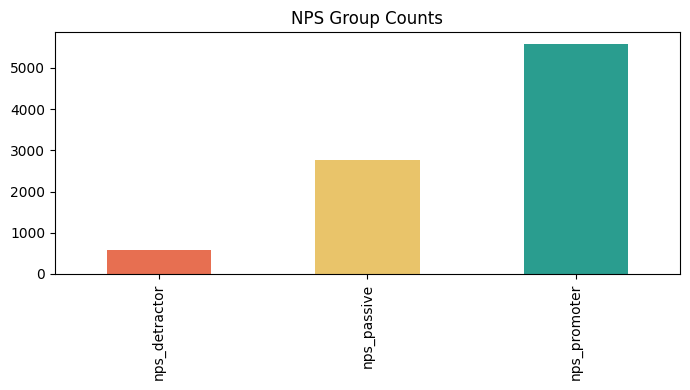

,count,pct
satisfied_yes,3298.0,93.27
satisfied_no,238.0,6.73


,promoter_rate_pct
business_location,
Addis Ketema,100.0
Lideta,100.0
Zone E,100.0
Awbarre Town,100.0
Zone B,100.0
...,...
Ruhango,0.0
Homasha Woreda,0.0
Nyaruguru,0.0


,promoter_rate_pct
business_sector,
Hospitality And Tourism Ð Restaurant/Bar,100.00
Retail Or Wholesale Shop,100.00
Manufacturing _non-food_,100.00
Livestock,100.00
Agribusiness_ Processing_ and Farming,85.42
...,...
Logistics/Shipping & Transportation,33.33
Transportation,33.33
Wholesale and General Trading,14.29


In [11]:
nps_cols = [c for c in ['nps_detractor', 'nps_passive', 'nps_promoter'] if c in df.columns]
sat_cols = [c for c in ['satisfied_yes', 'satisfied_no'] if c in df.columns]

if nps_cols:
    nps_totals = df[nps_cols].sum(numeric_only=True).rename('count').to_frame()
    nps_totals['pct'] = (nps_totals['count'] / nps_totals['count'].sum() * 100).round(2)
    display(nps_totals)

    fig, ax = plt.subplots(figsize=(7, 4))
    nps_totals['count'].plot(kind='bar', ax=ax, color=['#e76f51', '#e9c46a', '#2a9d8f'])
    ax.set_title('NPS Group Counts')
    plt.tight_layout()
    plt.show()

if sat_cols:
    sat_totals = df[sat_cols].sum(numeric_only=True).rename('count').to_frame()
    sat_totals['pct'] = (sat_totals['count'] / sat_totals['count'].sum() * 100).round(2)
    display(sat_totals)

if set(['business_location', 'nps_promoter']).issubset(df.columns):
    loc_promoter = df.groupby('business_location')['nps_promoter'].mean().sort_values(ascending=False)
    display((loc_promoter * 100).round(2).rename('promoter_rate_pct').to_frame())

if set(['business_sector', 'nps_promoter']).issubset(df.columns):
    sec_promoter = df.groupby('business_sector')['nps_promoter'].mean().sort_values(ascending=False)
    display((sec_promoter * 100).round(2).rename('promoter_rate_pct').to_frame())

In [12]:
checks = {}

if set(['nps_detractor', 'nps_passive', 'nps_promoter']).issubset(df.columns):
    nps_sum = df[['nps_detractor', 'nps_passive', 'nps_promoter']].sum(axis=1)
    checks['nps_not_one_hot'] = int((nps_sum != 1).sum())

if set(['satisfied_yes', 'satisfied_no']).issubset(df.columns):
    sat_sum = df[['satisfied_yes', 'satisfied_no']].sum(axis=1)
    checks['satisfaction_not_binary_pair'] = int((sat_sum != 1).sum())

for c in ['revenue', 'hh_expense', 'monthly_customer', 'job_created']:
    if c in df.columns:
        checks[f'negative_{c}'] = int((df[c] < 0).sum())

display(pd.Series(checks, name='count').sort_values(ascending=False).to_frame())

print('Executive Summary Prompts:')
print('- Validate data quality first where NPS/satisfaction encodings are inconsistent.')
print('- Prioritize locations and sectors with low promoter rates and weak economic outcomes.')
print('- Compare with baseline to estimate direction and magnitude of change.')

,count
satisfaction_not_binary_pair,5440
nps_not_one_hot,38
negative_revenue,0
negative_hh_expense,0
negative_monthly_customer,0
negative_job_created,0


Executive Summary Prompts:
- Validate data quality first where NPS/satisfaction encodings are inconsistent.
- Prioritize locations and sectors with low promoter rates and weak economic outcomes.
- Compare with baseline to estimate direction and magnitude of change.
